# <center> Machine Learning in Computational Biology - Assignment #1</center>
### <center>*Spring 2026*</center>
### <center>*Epigenetic Age Prediction from DNA Methylation*</center>

---


### Libraries

In [1]:
import sys
from functions import *
sys.path.append(os.path.abspath("../src"))
print("Libraries successfully loaded")

Libraries successfully loaded


# Task 1 : Data Loading and Preprocessing
---

## 1.1 Data splitting



### a) Loading the data

In [2]:
dev_data,eval_data=loading_files("../data/development_data.csv","../data/evaluation_data.csv")

Development set (456, 1003)            age             ethnicity sex  cg16867657  cg06639320  cg24724428  \
sample_id                                                                      
GSM990554   79  Caucasian - European   M    0.672001    0.504461    0.331257   
GSM990278   46    Hispanic - Mexican   M    0.555411    0.389214    0.160708   
GSM990589   78  Caucasian - European   M    0.781318    0.554360    0.337578   
GSM990323   46    Hispanic - Mexican   F    0.542491    0.435584    0.228723   
GSM990116   59    Hispanic - Mexican   F    0.653190    0.466217    0.208453   

           cg07553761  cg22454769  cg06784991  cg21572722  ...  cg17321954  \
sample_id                                                  ...               
GSM990554    0.327287    0.572867    0.309496    0.444902  ...    0.174936   
GSM990278    0.230875    0.464971    0.223665    0.381837  ...    0.154691   
GSM990589    0.437668    0.645529    0.309615    0.505999  ...    0.213999   
GSM990323    0.231709

### b) Splitting the data
#### ~80% training - 20% validation split (stratified by age, seed=42)

In [3]:
train_data,val_data,eval_data=split_data(dev_data,eval_data)

        Split  Samples  Percentage
0       Train      364   79.824561
1  Validation       92   20.175439


## 1.2  Preprocessing

### Feature Handling

In [4]:
# Gathering feature groups
metadata,cpg,age=feature_gathering(dev_data)
print(f"Feature Info: \n Metadata:{metadata},CpG columns:{len(cpg)},Column of focus: {age}")
#Create feature sets
metadata_features = feature_set(dev_data, sets="metadata")
cpg_features = feature_set(dev_data, sets="cpg")
all_features = feature_set(dev_data, sets="all")
print("=====================")
print(f"Feature Count: \n Metadata:{len(metadata_features)}, CpG columns:{len(cpg_features)}, Total Features: {len(all_features)}")


Feature Info: 
 Metadata:['sex', 'ethnicity'],CpG columns:1000,Column of focus: age
Feature Count: 
 Metadata:2, CpG columns:1000, Total Features: 1002


## Feature Matrix

#### a) Feature scaling use of StandardScaler to CpG features inside a sklearn Pipeline
#### b) Categorical features: Metadata columns are categorical resulting in the use of encoding for numerical representation.

In [5]:
results, summary_df = feature_matrices(train_data, val_data, eval_data)
summary_df

,feature_set,train,train_processed,val,val_processed,evaluation,evaluation_processed
0,metadata,"(364, 2)","(364, 4)","(92, 2)","(92, 4)","(100, 2)","(100, 4)"
1,cpg,"(364, 1000)","(364, 1000)","(92, 1000)","(92, 1000)","(100, 1000)","(100, 1000)"
2,all,"(364, 1002)","(364, 1004)","(92, 1002)","(92, 1004)","(100, 1002)","(100, 1004)"


## 1.3 Exploratory Analysis

## Dataset statistics table


In [6]:
stats_tab = data_summary(train_data,val_data,eval_data,results=results,features="all")
stats_tab

,dataset,samples,age_mean ± std,age_range,sex_balance,ethnicity_balance,total_missing_values_raw,processed_shape,total_missing_values_processed
0,Train,364,64.5 ± 14.6,19 - 101,"{'M': 191, 'F': 173}","{'Caucasian - European': 246, 'Hispanic - Mexi...",10965,"(364, 1004)",0
1,Validation,92,64.2 ± 14.7,25 - 89,"{'F': 51, 'M': 41}","{'Caucasian - European': 62, 'Hispanic - Mexic...",2747,"(92, 1004)",0
2,Evaluation,100,62.5 ± 14.3,21 - 92,"{'F': 58, 'M': 42}","{'Caucasian - European': 56, 'Hispanic - Mexic...",3058,"(100, 1004)",0


## Age Distribution Plot of Development Dataset


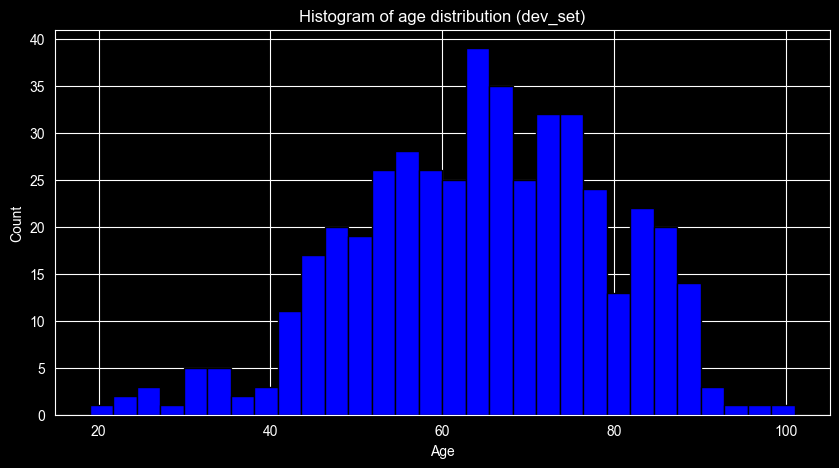

In [7]:
age_distribution_plot(dev_data["age"])

## Age Distribution Plots of Each Dataset

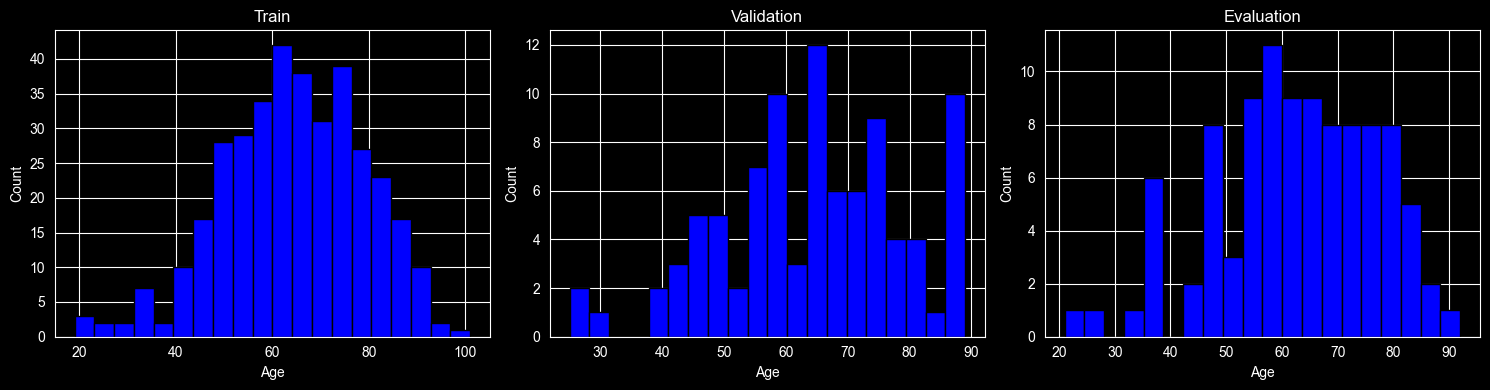

In [8]:
age_split_plot(train_data,val_data,eval_data)

---

# Task 2: Baseline Models
---

 ## 2.1  OLS LinearRegression across feature sets
#### a) Train OLS LinearRegression model per feature set
#### b) Evaluation on the validation set using bootstrap resampling of the validation predictions (1000 resamples, seed=42)


In [9]:
ols_results,ols_summary=ols_all_featuresets(results,n_bootstrap=1000,seed=42)
ols_summary

Evaluation completed
Train OLS LinearRegression for metadata
Evaluation completed
Train OLS LinearRegression for cpg
Evaluation completed
Train OLS LinearRegression for all


,feature_set,RMSE,RMSE_95CI,MAE,MAE_95CI,R2,R2_95CI,Pearson_r,Pearson_95CI
0,metadata,12.9545,10.5730 - 15.4597,9.8540,8.2067 - 11.7093,0.2138,0.0510 - 0.3648,0.4629,0.2991 - 0.6253
1,cpg,5.2731,4.0635 - 6.5458,4.0006,3.2965 - 4.6899,0.8697,0.7875 - 0.9235,0.9355,0.8930 - 0.9650
2,all,5.2576,4.0582 - 6.5256,3.9915,3.2988 - 4.6716,0.8705,0.7878 - 0.9243,0.9360,0.8937 - 0.9654


## 2.2  Three regression models at default hyperparameters
#### a) ElasticNet - L1+L2 regularized linear regression
#### b) SVR - Support Vector Regression with RBF kernel
#### c) BayesianRidge - Bayesian Linear regression
---

### **Training the 3 algorithms at default hyperparameters on the CpG-only feature set**

#### a) CpG-only feature set

In [10]:
X_train_cpg = results["cpg"]["X_train_processed"]
X_val_cpg = results["cpg"]["X_val_processed"]
y_train = results["cpg"]["y_train"]
y_val = results["cpg"]["y_val"]

#### b) Training

In [11]:
#ElasticNet
elastic_model, elastic_pred = model_elasticnet(X_train_cpg, y_train, X_val_cpg)
elastic_results = evaluation_of_model(y_val, elastic_pred)
#SVR
svr_fit, svr_pred = svr_model(X_train_cpg, y_train, X_val_cpg)
svr_results = evaluation_of_model(y_val, svr_pred)
#BayesianRidge
bayes_model, bayes_pred = bayesianridge_model(X_train_cpg, y_train, X_val_cpg)
bayes_results = evaluation_of_model(y_val, bayes_pred)

############### Training ElasticNet ###############
Evaluation completed
############### Training SVR ###############
Evaluation completed
############### Training BayesianRidge ###############
Evaluation completed


#### Creating dict with the results for report table/boxplot

In [12]:
task22_results = {
    "OLS": ols_results["cpg"]["metrics"],
    "ElasticNet": elastic_results,
    "SVR": svr_results,
    "BayesianRidge": bayes_results
}

### **Models Comparison with the OLS floor**
#### Table with RMSE mean, 95% CI, MAE, R², and Pearson r for all baselines


In [13]:
report_df = report_table(task22_results)
#report_df

Report table of model performance:
        Model RMSE mean      RMSE 95% CI MAE mean      MAE 95% CI R^2 mean      R^2 95% CI Pearson r mean Pearson r 95% CI
          OLS    5.2279  4.0635 - 6.5458   3.9824 3.2965 - 4.6899   0.8669 0.7875 - 0.9235         0.9351  0.8930 - 0.9650
   ElasticNet    5.4901  4.3695 - 6.8731   4.0946 3.3488 - 4.8785   0.8538 0.7707 - 0.9109         0.9325  0.8886 - 0.9632
          SVR    8.8880 7.2349 - 10.6252   6.4898 5.3430 - 7.8107   0.6239 0.5374 - 0.7041         0.8466  0.7804 - 0.8984
BayesianRidge    4.6876  3.6219 - 5.9787   3.5233 2.9191 - 4.1763   0.8928 0.8252 - 0.9401         0.9496  0.9134 - 0.9734


### Comparison bootstrap boxplots for RMSE and R² for all models

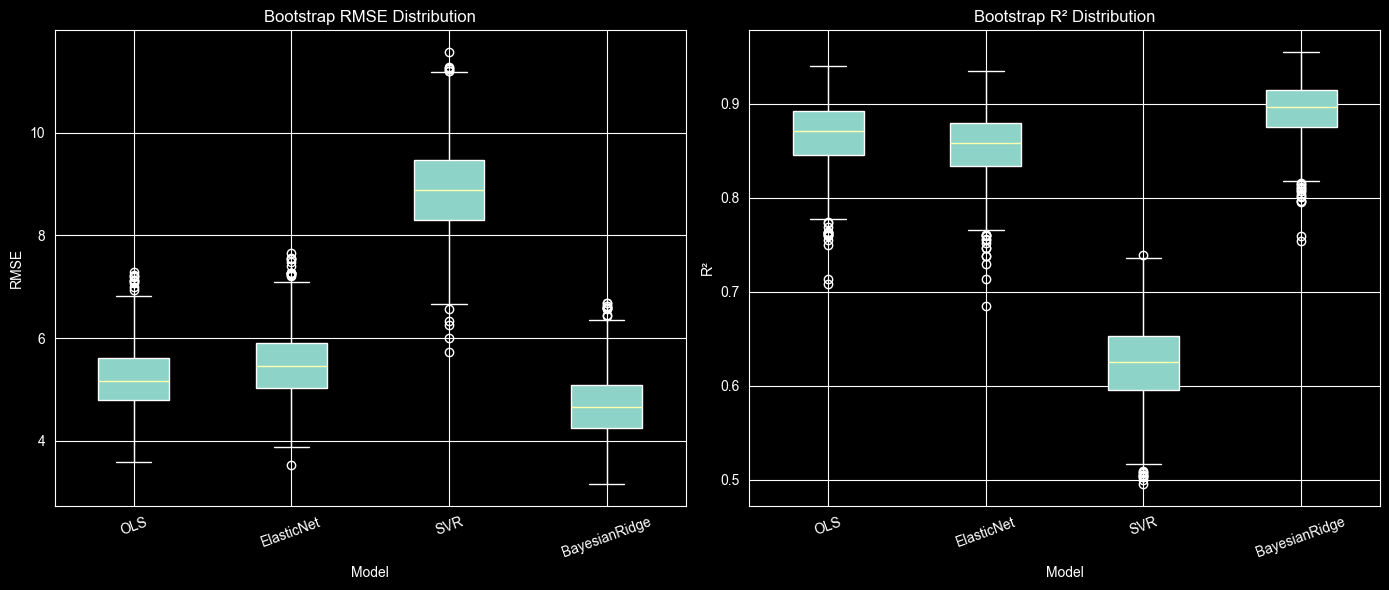

In [14]:
bootstrap_boxplots(task22_results)

#### Comparison of RMSE & R² shows: **BayesianRidge beating the OLS floor**

In [15]:
comparison_df = compare_with_ols({"ElasticNet": elastic_results,"SVR": svr_results,"BayesianRidge": bayes_results},
    ols_results["cpg"]["metrics"])
comparison_df

,Model,RMSE,R²,Beats OLS
0,ElasticNet,5.5131,0.8576,False
1,SVR,8.9233,0.6270,False
2,BayesianRidge,4.7284,0.8953,True


### Additional Analysis: Train vs Validation Performance

In [16]:
#Checking for overfitting
models = {"OLS": ols_results["cpg"]["model"],"EN": elastic_model,"SVR": svr_fit,"BR": bayes_model}
train_val = train_vs_val_all_models(models, X_train_cpg, y_train, X_val_cpg, y_val)
train_val

,Model,Train RMSE,Val RMSE,Train R^2,Val R^2
0,OLS,7.348968e-14,5.273076,1.000000,0.869735
1,EN,3.841868e+00,5.513114,0.930916,0.857606
2,SVR,8.414715e+00,8.923338,0.668584,0.626962
3,BR,1.132770e+00,4.728381,0.993994,0.895257


#### **_Comment_** --> BayesianRidge seems to achieve better generalization with smaller train-validation gaps than OLS that seems to overfitting.

---


# Task 3: Feature Selection
---

## 3.1  Stability Selection

Resample regeneration: 10/50 completed
Resample regeneration: 20/50 completed
Resample regeneration: 30/50 completed
Resample regeneration: 40/50 completed
Resample regeneration: 50/50 completed
The stable features are: 188


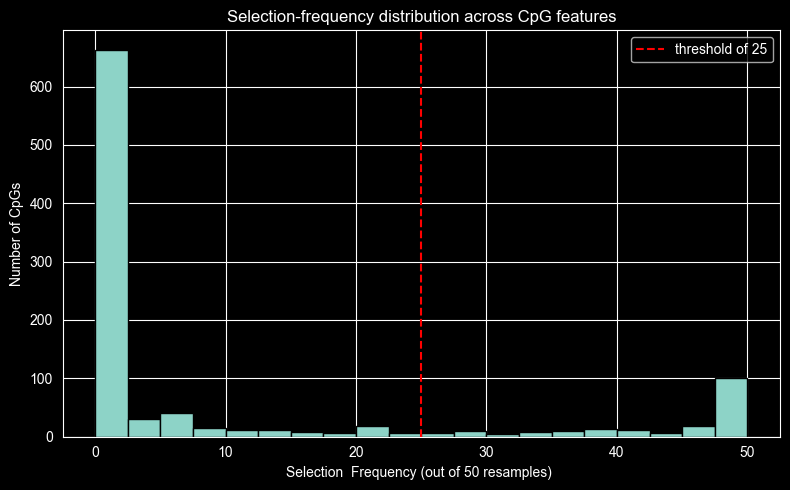

In [17]:
stable_features,selections_counts=stability_selection(train_data)
frequencyplot(selections_counts)


## 3.2   Minimum Redundancy Maximum Relevance  (mRMR)

### Choosing a K value

Testing k: 40


100%|██████████| 40/40 [00:06<00:00,  5.90it/s]


K: 40 with Validation RMSE: 5.6825 and Validation R^2: 0.8487
Testing k: 60


100%|██████████| 60/60 [00:10<00:00,  5.96it/s]


K: 60 with Validation RMSE: 5.6982 and Validation R^2: 0.8479
Testing k: 80


...

K: 150 with Validation RMSE: 5.6387 and Validation R^2: 0.8510
Testing k: 180


100%|██████████| 180/180 [00:29<00:00,  6.06it/s]


K: 180 with Validation RMSE: 5.6632 and Validation R^2: 0.8497
Testing k: 200


100%|██████████| 200/200 [00:32<00:00,  6.14it/s]


K: 200 with Validation RMSE: 5.5369 and Validation R^2: 0.8564

The best chosen K is: 100.0 with Validation RMSE: 5.3803 and Validation R^2:0.8644


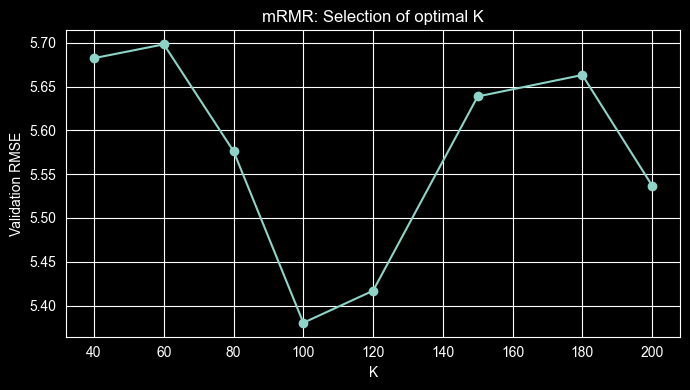

,K,Validation RMSE,Validation R^2
0,40,5.682465,0.848723
1,60,5.698238,0.847882
2,80,5.576162,0.854330
3,100,5.380260,0.864386
4,120,5.416887,0.862533
5,150,5.638716,0.851044
6,180,5.663219,0.849746
7,200,5.536895,0.856375


In [18]:
b_k,results = choosing_k_value(train_data,val_data)
results

### Running mRMR with best choosen K

In [19]:
mrmr_features,top10_mrmr=mrmr_function(train_data,b_k)


100%|██████████| 100/100 [00:18<00:00,  5.35it/s]

Selected mRMR 100 features.

Top 10 selected features:
 Rank    Feature  Proxy importance (Spearman r)
    1 cg16867657                       0.855651
    2 cg06639320                       0.760184
    3 cg10501210                       0.700527
    4 cg24724428                       0.765116
    5 cg22454769                       0.727123
    6 cg21572722                       0.713279
    7 cg19283806                       0.665947
    8 cg14692377                       0.696441
    9 cg08234504                       0.704110
   10 cg24079702                       0.706200


### Overlap between Stability & mRMR

Stability:  103
Overlap:  85
mRMR:  15


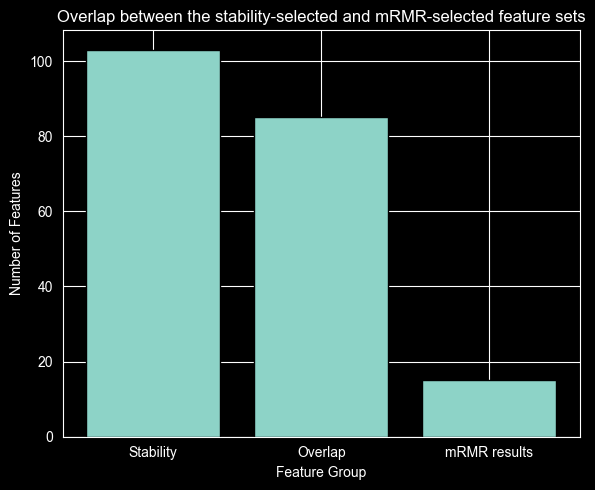

,Group,Count
0,Stability,103
1,Overlap,85
2,mRMR results,15


In [20]:
overlapping_plot(stable_features.index,mrmr_features)

## 3.3  Method comparison & Selection

In [21]:
comparison_df,selected_features,selected_method=feature_comparison(train_data,val_data,stable_features,mrmr_features,b_k)

############### Training BayesianRidge ###############

  Stability Selection 
Number of selected features : 188
Validation RMSE  : 5.5272
Validation R^2 : 0.8569
############### Training BayesianRidge ###############

  mRMR 
Number of selected features : 100
Chosen K  : 100.0
Validation RMSE  : 5.5837
Validation R^2 : 0.8539

Feature selection summary-comparison
             Method  Number of Features Chosen K  Validation RMSE  Validation R^2
Stability Selection                 188        -         5.527232        0.856876
               mRMR                 100    100.0         5.583722        0.853935
Selected method (later use): Stability Selection
Number of features kept : 188
Best validation RMSE : 5.5272


---

# Task 4: Hyperparameter Tuning and Final Evaluation

----

## 4.1  Hyperparameter tuning

In [22]:
#Tuning
best_models,tuning_results=model_tuning(dev_data,selected_features,trails=40,seed=42)
tuning_results


Hyperparameter tuning on full dev_data
188
____Tuning____
ElasticNet
SVR
BayesianRidge


,Model,Best RMSE,Best Params
0,ElasticNet,5.085293,"{'model__alpha': 0.2801635158716261, 'model__l..."
1,SVR,5.330520,"{'model__C': 17.67218232266506, 'model__epsilo..."
2,BayesianRidge,5.199456,"{'model__alpha_1': 3.798214508453255e-07, 'mod..."


## 4.2  Final model evaluation

### Fs-only evaluation

In [23]:
elastic_fs, svr_fs, bayes_fs = fs_eval_models(train_data,val_data,selected_features)

############### Training ElasticNet ###############
############### Training SVR ###############
############### Training BayesianRidge ###############
Evaluation completed
Evaluation completed
Evaluation completed


### Tuned models & Results

In [24]:
elastic_tuned_results = evaluation(best_models["ElasticNet"],eval_data,selected_features)
svr_tuned_results = evaluation(best_models["SVR"],eval_data,selected_features)
bayes_tuned_results = evaluation(best_models["BayesianRidge"],eval_data,selected_features)
# Tuned results all together
tuned_results={"ElasticNet":elastic_tuned_results,"SVR":svr_tuned_results,"BayesianRidge":bayes_tuned_results}


Evaluating with evaluation data

Evaluation of all three tuned models on the evaluation set using bootstrap resampling:
RMSE: mean=5.0711, std=0.5591, 95% CI=(4.0213, 6.1896)
MAE: mean=3.7238, std=0.3482, 95% CI=(3.0846, 4.4590)
R²: mean=0.8683, std=0.0360, 95% CI=(0.7807, 0.9285)
Pearson r : mean=0.9340, std=0.0182, 95% CI=(0.8916, 0.9643)

Evaluating with evaluation data

Evaluation of all three tuned models on the evaluation set using bootstrap resampling:
RMSE: mean=5.3781, std=0.4739, 95% CI=(4.5406, 6.4017)
MAE: mean=4.1790, std=0.3339, 95% CI=(3.5581, 4.8848)
R²: mean=0.8530, std=0.0333, 95% CI=(0.7730, 0.9077)
Pearson r : mean=0.9258, std=0.0169, 95% CI=(0.8851, 0.9536)

Evaluating with evaluation data

Evaluation of all three tuned models on the evaluation set using bootstrap resampling:
RMSE: mean=5.2068, std=0.5509, 95% CI=(4.1567, 6.3498)
MAE: mean=3.9070, std=0.3496, 95% CI=(3.2637, 4.6294)
R²: mean=0.8612, std=0.0371, 95% CI=(0.7728, 0.9244)
Pearson r : mean=0.9317, std=

### Boxplots

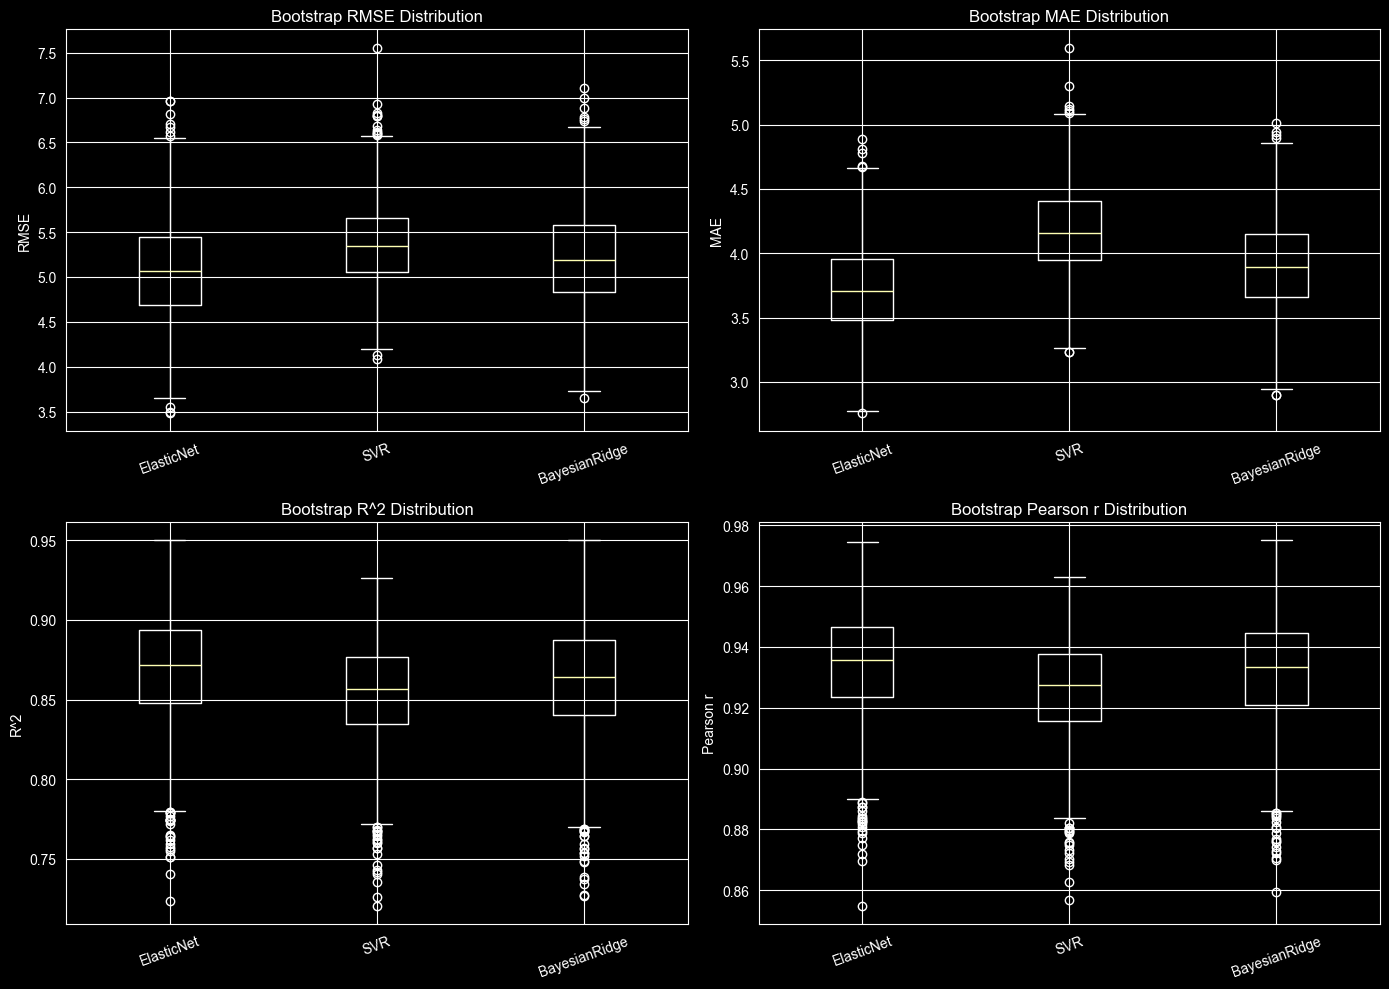

In [25]:
bootstrap_boxplots_4_2(tuned_results)


### Scatter plots

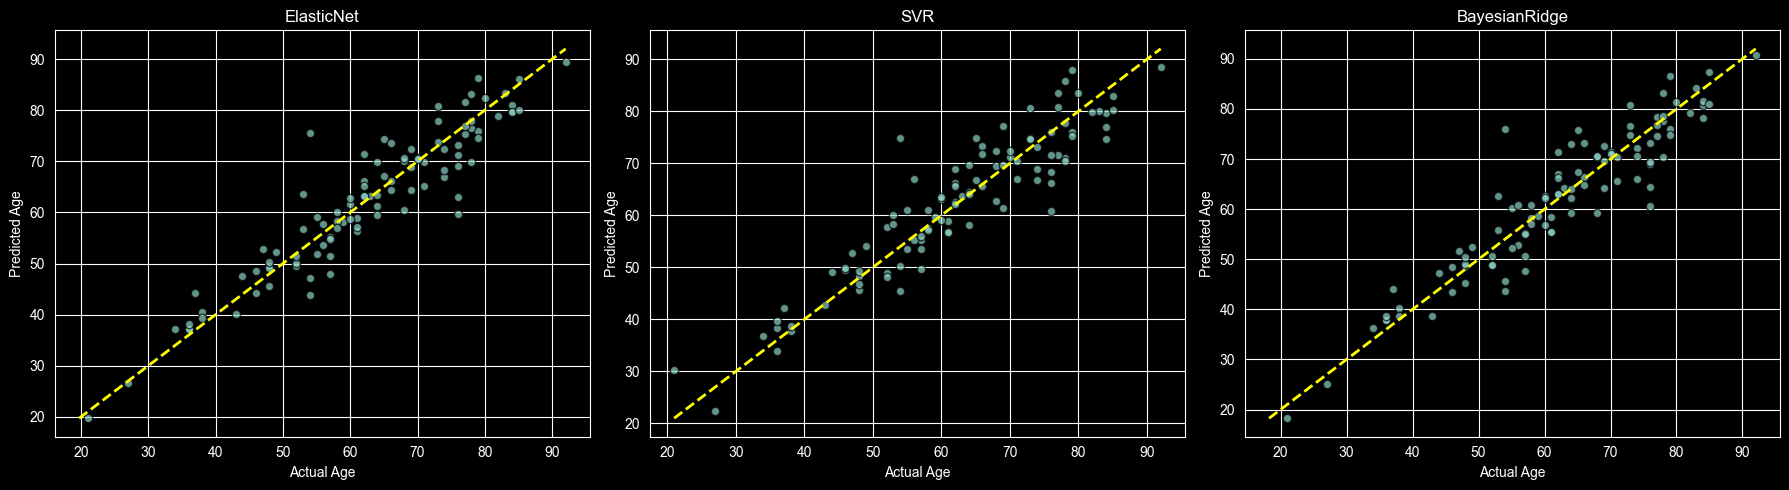

In [26]:
scatter_plot_realvspredicted(best_models,eval_data,selected_features)

### Stage Tables

In [27]:
elastic_stage_results = {"Baseline": elastic_results,"FS-only": elastic_fs,"FS+Tuned": elastic_tuned_results}
elastic_stage_table = query_table("ElasticNet", elastic_stage_results)

svr_stage_results = {"Baseline": svr_results,"FS-only": svr_fs,"FS+Tuned": svr_tuned_results}
svr_stage_table = query_table("SVR", svr_stage_results)


bayes_stage_results ={"Baseline":bayes_results,"Fs-only":bayes_fs,"Fs+Tuned":bayes_tuned_results}
bayes_stage_table = query_table("BayesianRidge", bayes_stage_results)


In [28]:
final_table=pd.concat([elastic_stage_table,svr_stage_table,bayes_stage_table],ignore_index=True)
final_table

,Model,Stage,RMSE (mean),95% CI,MAE,R²,Pearson r
0,ElasticNet,Baseline,5.490,"[4.370, 6.873]",4.095,0.854,0.932
1,ElasticNet,FS-only,5.841,"[4.615, 7.346]",4.395,0.835,0.923
2,ElasticNet,FS+Tuned,5.071,"[4.021, 6.190]",3.724,0.868,0.934
3,SVR,Baseline,8.888,"[7.235, 10.625]",6.490,0.624,0.847
4,SVR,FS-only,8.247,"[6.655, 10.016]",5.895,0.676,0.867
5,SVR,FS+Tuned,5.378,"[4.541, 6.402]",4.179,0.853,0.926
6,BayesianRidge,Baseline,4.688,"[3.622, 5.979]",3.523,0.893,0.950
7,BayesianRidge,Fs-only,5.511,"[4.457, 6.772]",4.119,0.853,0.930
8,BayesianRidge,Fs+Tuned,5.207,"[4.157, 6.350]",3.907,0.861,0.932


## 4.3  Model selection & Final model

In [29]:
tuned_models = {"ElasticNet": best_models["ElasticNet"],"SVR": best_models["SVR"],"BayesianRidge": best_models["BayesianRidge"]}
best_model_name, best_model, best_model_path = selection_save_final(tuned_results=tuned_results,tuned_models=tuned_models,model_dir="../models")


Final model selection
----------------------------------------
ElasticNet      RMSE(mean): 5.0711
SVR             RMSE(mean): 5.3781
BayesianRidge   RMSE(mean): 5.2068
----------------------------------------
Selected best model: ElasticNet
Best RMSE(mean): 5.0711
Model saved
Model loaded


## Best Model Results

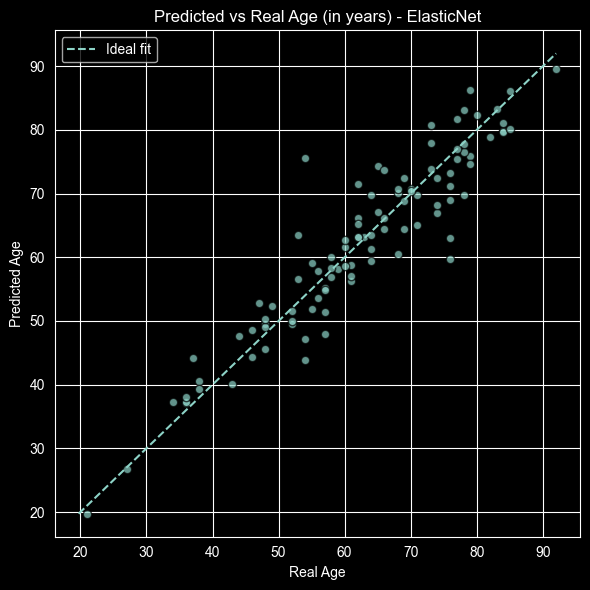

In [30]:
X_eval = eval_data[selected_features]
y_eval = eval_data["age"].values
y_predict = best_model.predict(X_eval)

plot_best_model_real_predict(y_eval, y_predict, best_model_name)

### *Comment* --> ElasticNet --> Selected as the final model lowest bootstrap RMSE mean **(5.0711)**

# Bonus A: Optuna Hyperparameter Optimization
---

### Optuna Running

In [31]:
best_models_optuna, tuning_results_optuna, optuna_studies = optuna_tune_all_models(dev_data, selected_features, n_trials=40, cv=5, seed=42)
tuning_results_optuna

[I 2026-04-01 22:40:36,193] A new study created in memory with name: no-name-23b45b0e-30f2-4907-ad4e-9f6b276486bb



Optuna tuning: ElasticNet


[I 2026-04-01 22:40:36,556] Trial 0 finished with value: 5.747050065423254 and parameters: {'alpha': 0.03148911647956861, 'l1_ratio': 0.9556428757689246}. Best is trial 0 with value: 5.747050065423254.
[I 2026-04-01 22:40:36,691] Trial 1 finished with value: 5.286307604089304 and parameters: {'alpha': 0.8471801418819978, 'l1_ratio': 0.6387926357773329}. Best is trial 1 with value: 5.286307604089304.
[I 2026-04-01 22:40:41,847] Trial 2 finished with value: 6.613276282773337 and parameters: {'alpha': 0.004207988669606638, 'l1_ratio': 0.2403950683025824}. Best is trial 1 with value: 5.286307604089304.
[I 2026-04-01 22:40:42,338] Trial 3 finished with value: 6.747192910121603 and parameters: {'alpha': 0.0017073967431528124, 'l1_ratio': 0.8795585311974417}. Best is trial 1 with value: 5.286307604089304.
[I 2026-04-01 22:40:42,587] Trial 4 finished with value: 5.160116081690951 and parameters: {'alpha': 0.2537815508265665, 'l1_ratio': 0.737265320016441}. Best is trial 4 with value: 5.1601160


Optuna tuning: SVR


[I 2026-04-01 22:40:51,478] Trial 1 finished with value: 5.376591195786692 and parameters: {'C': 159.94091701280448, 'epsilon': 1.0, 'kernel': 'rbf'}. Best is trial 1 with value: 5.376591195786692.
[I 2026-04-01 22:40:52,224] Trial 2 finished with value: 6.148110612816285 and parameters: {'C': 0.4705059281907647, 'epsilon': 0.5, 'kernel': 'linear'}. Best is trial 1 with value: 5.376591195786692.
[I 2026-04-01 22:40:52,772] Trial 3 finished with value: 5.914497230466635 and parameters: {'C': 0.32808290847300486, 'epsilon': 1.0, 'kernel': 'linear'}. Best is trial 1 with value: 5.376591195786692.
[I 2026-04-01 22:42:07,151] Trial 4 finished with value: 7.188107222180891 and parameters: {'C': 15.535445807588452, 'epsilon': 0.1, 'kernel': 'linear'}. Best is trial 1 with value: 5.376591195786692.
[I 2026-04-01 22:50:05,662] Trial 5 finished with value: 7.159421583812632 and parameters: {'C': 97.77718780862641, 'epsilon': 0.5, 'kernel': 'linear'}. Best is trial 1 with value: 5.376591195786692


Optuna tuning: BayesianRidge


[I 2026-04-01 22:51:02,350] Trial 0 finished with value: 5.199460434929238 and parameters: {'alpha_1': 3.14891164795686e-06, 'alpha_2': 0.0006351221010640698, 'lambda_1': 8.471801418819978e-05, 'lambda_2': 2.481040974867808e-05}. Best is trial 0 with value: 5.199460434929238.
[I 2026-04-01 22:51:02,644] Trial 1 finished with value: 5.199466569256034 and parameters: {'alpha_1': 4.20798866960663e-07, 'alpha_2': 4.207053950287931e-07, 'lambda_1': 1.7073967431528095e-07, 'lambda_2': 0.0002915443189153752}. Best is trial 0 with value: 5.199460434929238.
[I 2026-04-01 22:51:02,949] Trial 2 finished with value: 5.199476465485642 and parameters: {'alpha_1': 2.5378155082656606e-05, 'alpha_2': 6.796578090758147e-05, 'lambda_1': 1.208754147305695e-07, 'lambda_2': 0.0007579479953348002}. Best is trial 0 with value: 5.199460434929238.
[I 2026-04-01 22:51:03,241] Trial 3 finished with value: 5.199460858538841 and parameters: {'alpha_1': 0.00021368329072358748, 'alpha_2': 7.068974950624599e-07, 'lamb

,Model,Best RMSE,Best Params,Trials
0,ElasticNet,5.109416,"{'alpha': 0.2053652060405282, 'l1_ratio': 0.16...",40
1,SVR,5.312138,"{'C': 23.503102330490893, 'epsilon': 0.1, 'ker...",40
2,BayesianRidge,5.199456,"{'alpha_1': 5.625103603684526e-07, 'alpha_2': ...",40


### Head-to head table

In [32]:
optuna_vs_random_table = compare_randomsearch_vs_optuna(tuning_results,tuning_results_optuna)
optuna_vs_random_table

        Model  RandomSearch RMSE  Optuna RMSE  Delta (Optuna - Random)       Winner
   ElasticNet             5.0853       5.1094                   0.0241 RandomSearch
          SVR             5.3305       5.3121                  -0.0184       Optuna
BayesianRidge             5.1995       5.1995                  -0.0000       Optuna


,Model,RandomSearch RMSE,Optuna RMSE,Delta (Optuna - Random),Winner
0,ElasticNet,5.0853,5.1094,0.0241,RandomSearch
1,SVR,5.3305,5.3121,-0.0184,Optuna
2,BayesianRidge,5.1995,5.1995,-0.0000,Optuna


### Optimization history for ElasticNet

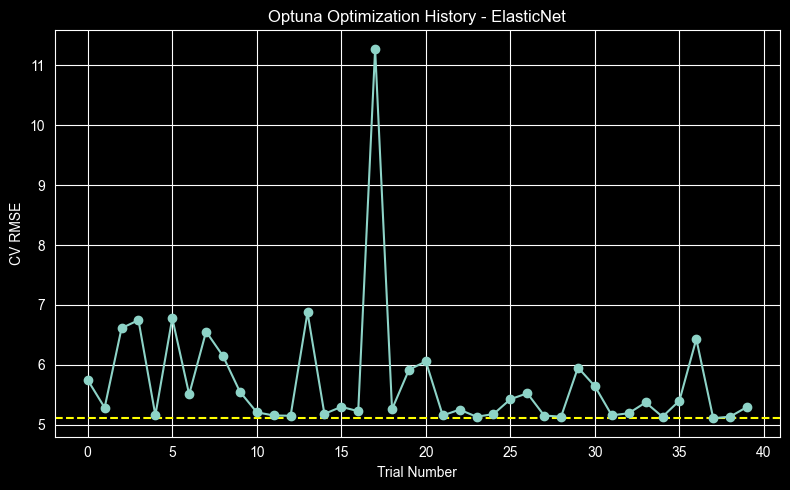

In [33]:
plot_optuna_history(optuna_studies["ElasticNet"], model_name ="ElasticNet",path="../figures/optuna_history_elastincnet.png")

---

# Bonus B: Sex Prediction from DNA Methylation
---

### 1. Creating the labels

In [34]:
train_data,val_data,eval_data=sex_label(train_data,val_data,eval_data)

Sex labels created: F=0, M=1


### 2. Selecting Sex features

In [35]:
sex_features=sex_features(train_data,b_k)

Running mRMR classification --> K=100


100%|██████████| 100/100 [00:16<00:00,  6.13it/s]

Selected 100 sex-related CpG features


### 3. Overlap Age vs Sex features


Age: 181
Overlap: 7
Sex: 93


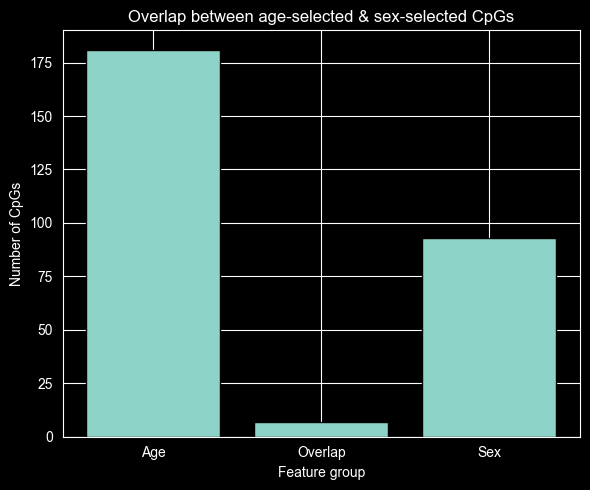

In [36]:
plot_sexvsage_overlap(selected_features,sex_features)

### 4. Preparing Processed data

In [37]:
X_train_sex,X_eval_sex,y_train_sex,y_eval_sex,sex_preprocessor=prepare_sex_classification_data(train_data, eval_data, sex_features)

### 5. Models' Training


In [38]:
lr_model,gnb_model=training_classifiers(X_train_sex,y_train_sex)

Training Logistic Regression
Training Gaussian Naive Bayes
Classification models --> Trained 


### 6. Bootstrap Evaluation

In [39]:
lr_results=evaluate_classifier(lr_model,X_eval_sex,y_eval_sex,bootstrap=1000,seed=42)
gnb_results=evaluate_classifier(gnb_model,X_eval_sex,y_eval_sex,bootstrap=1000,seed=42)

Completed
Accuracy : 0.9100 (95% CI: 0.8500 - 0.9600)
F1       : 0.8889 (95% CI: 0.8055 - 0.9495)
MCC      : 0.8150 (95% CI: 0.6955 - 0.9168)
ROC-AUC  : 0.9327 (95% CI: 0.8772 - 0.9778)
PR-AUC   : 0.9353 (95% CI: 0.8706 - 0.9772)
Completed
Accuracy : 0.6400 (95% CI: 0.5400 - 0.7300)
F1       : 0.5610 (95% CI: 0.4117 - 0.6804)
MCC      : 0.2564 (95% CI: 0.0507 - 0.4350)
ROC-AUC  : 0.6954 (95% CI: 0.5890 - 0.7948)
PR-AUC   : 0.5581 (95% CI: 0.4238 - 0.7206)


### 7. Required Table

In [40]:
sex_results_dict={"Logistic Regression":lr_results,"Gaussian NB":gnb_results}
sex_results_table=sex_classification_table(sex_results_dict,features_label=len(sex_features))
sex_results_table

              Model    Accuracy (95% CI)          F1 (95% CI)         MCC (95% CI)     ROC-AUC (95% CI)      PR-AUC (95% CI)  Feature
Logistic Regression 0.911 [0.850, 0.960] 0.888 [0.806, 0.950] 0.816 [0.696, 0.917] 0.933 [0.877, 0.978] 0.935 [0.871, 0.977]      100
        Gaussian NB 0.637 [0.540, 0.730] 0.553 [0.412, 0.680] 0.250 [0.051, 0.435] 0.694 [0.589, 0.795] 0.564 [0.424, 0.721]      100


,Model,Accuracy (95% CI),F1 (95% CI),MCC (95% CI),ROC-AUC (95% CI),PR-AUC (95% CI),Feature
0,Logistic Regression,"0.911 [0.850, 0.960]","0.888 [0.806, 0.950]","0.816 [0.696, 0.917]","0.933 [0.877, 0.978]","0.935 [0.871, 0.977]",100
1,Gaussian NB,"0.637 [0.540, 0.730]","0.553 [0.412, 0.680]","0.250 [0.051, 0.435]","0.694 [0.589, 0.795]","0.564 [0.424, 0.721]",100


### 8. Confusion matrices

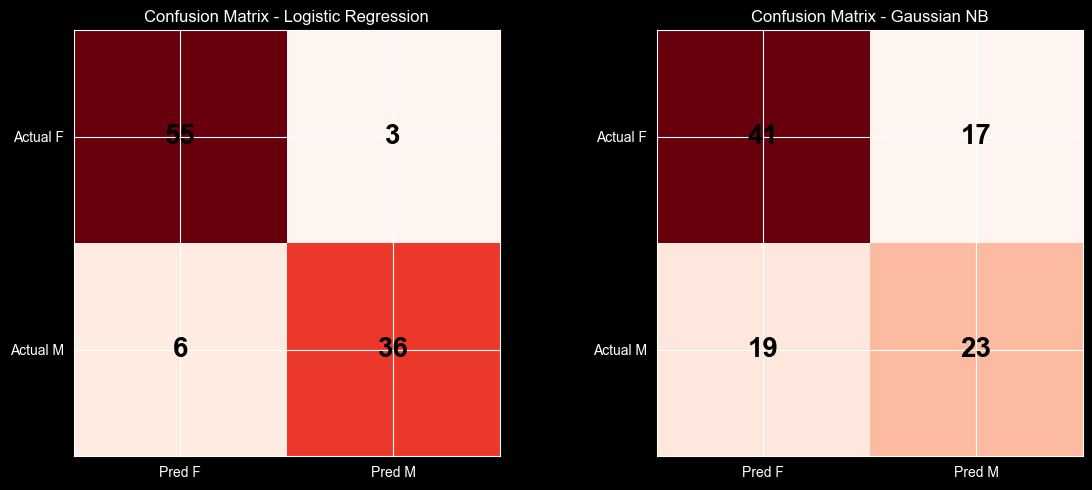

In [41]:
plot_confusion_matrices(lr_model,gnb_model, X_eval_sex,y_eval_sex)

### 9. ROC curves

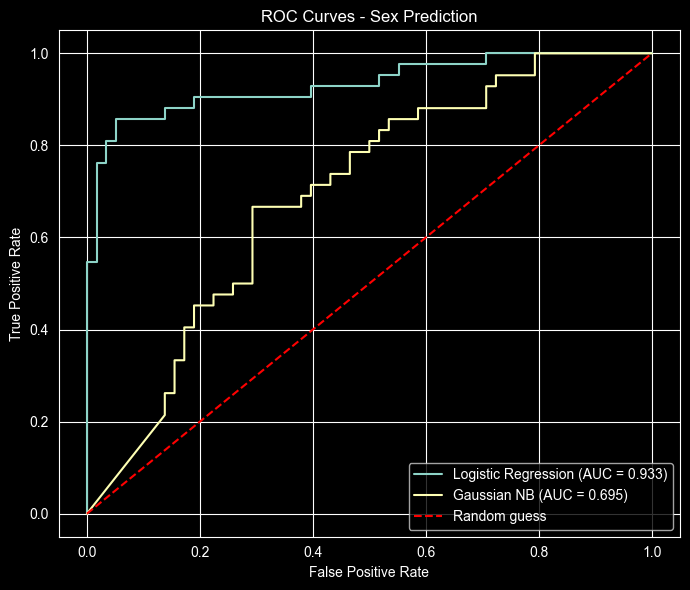

In [42]:
plot_roc_curves(lr_model,gnb_model,X_eval_sex, y_eval_sex)

### 10. Plot of Top 20 sex CpGs

Calculating |point-biserial r| for CpGs vs sex
cg05207637 r=0.32624468679843965


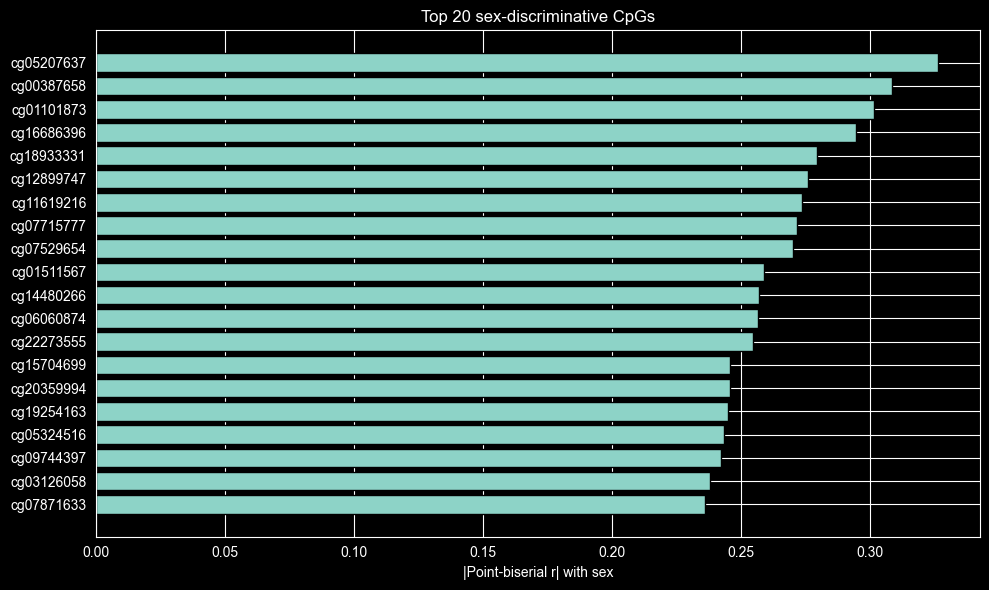

In [43]:
plot_top20_sex_cpgs(train_data)

### 11. Bootstrap Boxplots for all  metrics

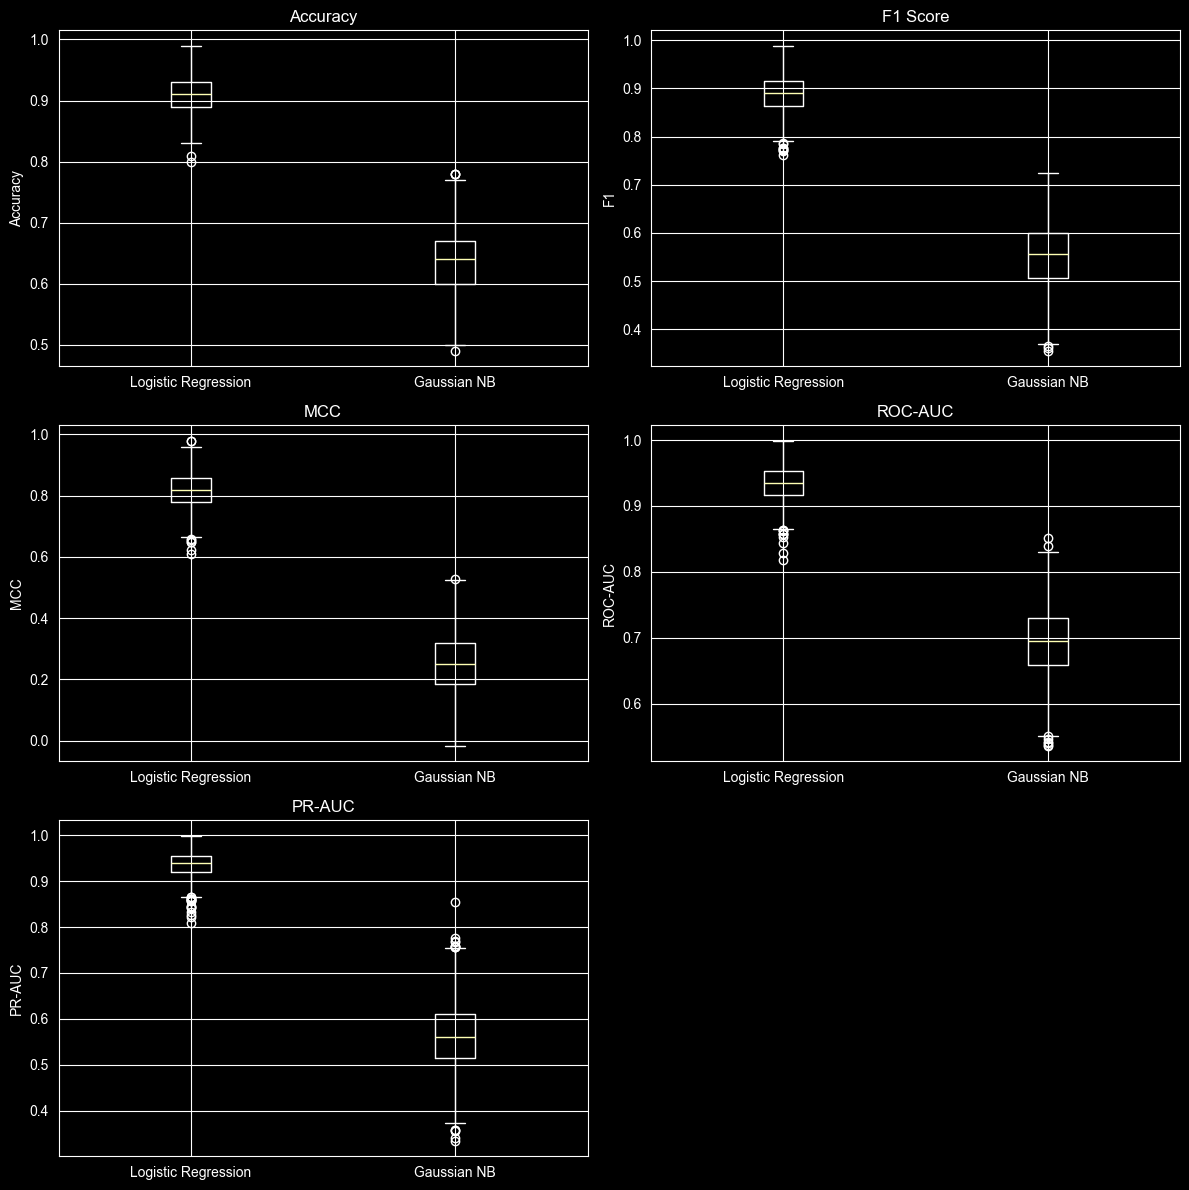

In [44]:
classifier_boxplots(lr_results,gnb_results,path="../figures/classifier_boxplots.png")